In [1]:
pip install pandas scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

In [5]:
data = pd.read_csv("sentimentdataset.csv")
data.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
print(data.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [8]:
def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    return text
data['clean_text'] = data['Text'].apply(clean_text)

In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['clean_text'])
y = data['Sentiment']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2%}")

Model Accuracy: 2312.93%


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            1.00      1.00      1.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
        ArtisticBurst        0.00      0.00      0.00         0
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [13]:
def predict_sentiment(new_text):
    cleaned = clean_text(new_text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)
    return prediction[0]
sample_text = "I am so happy with how this project is turning out!"
print(f"Text: {sample_text}")
print(f"Predicted Sentiment: {predict_sentiment(sample_text)}")

Text: I am so happy with how this project is turning out!
Predicted Sentiment:  Positive  


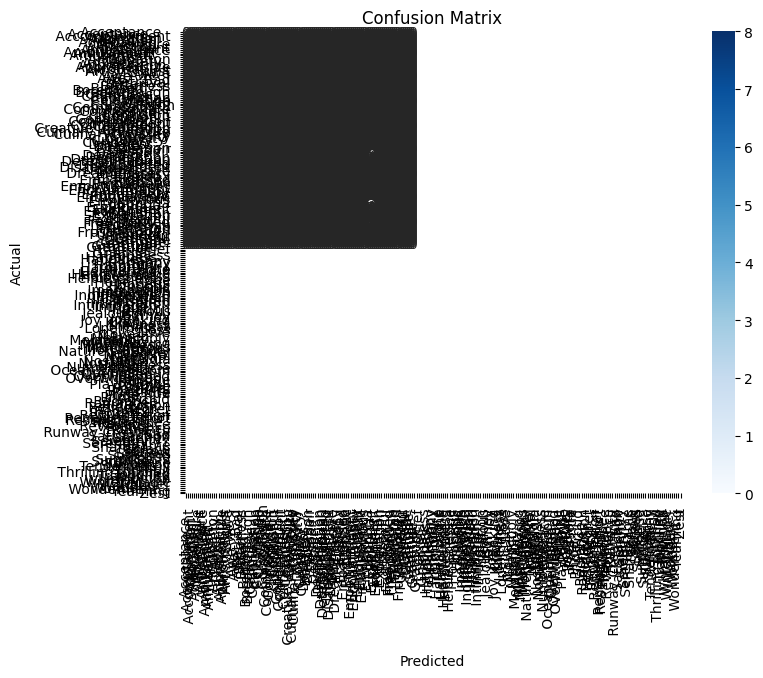

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
data['Sentiment'] = data['Sentiment'].str.strip()

In [16]:
import joblib
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("Model saved successfully!")

Model saved successfully!


In [17]:
y = data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print(f"New Accuracy: {model.score(X_test, y_test) * 100:.2%}")

New Accuracy: 3673.47%


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13016\1250667371.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data[data['Sentiment'].isin(top_sentiments)],


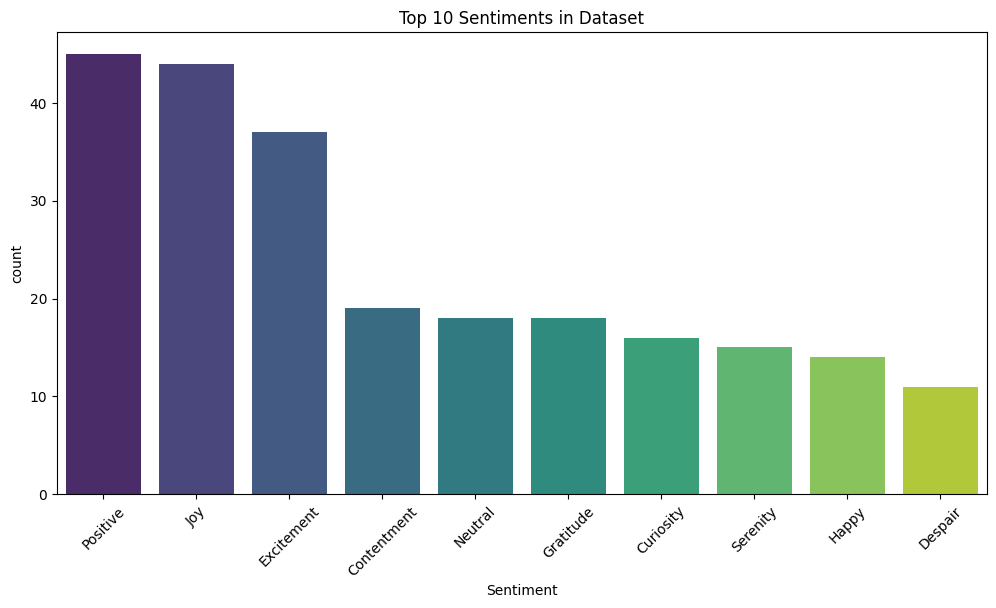

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
top_sentiments = data['Sentiment'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data=data[data['Sentiment'].isin(top_sentiments)], 
              x='Sentiment', 
              order=top_sentiments,
              palette='viridis')
plt.title('Top 10 Sentiments in Dataset')
plt.xticks(rotation=45)
plt.show()

In [20]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


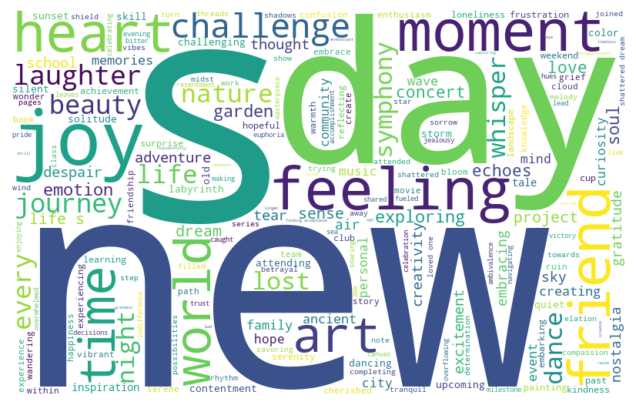

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
all_words = ' '.join([text for text in data['clean_text']])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [22]:
def group_sentiment(sentiment):
    positives = ['Positive', 'Joy', 'Happiness', 'Excitement', 'Awe', 'Contentment', 'Elation', 'Admiring', 'Hopeful', 'Proud']
    negatives = ['Negative', 'Anger', 'Fear', 'Sadness', 'Disgust', 'Bitter', 'Loneliness', 'Grief', 'Frustration', 'Hate']
    
    if any(word in sentiment for word in positives):
        return 'Positive'
    elif any(word in sentiment for word in negatives):
        return 'Negative'
    else:
        return 'Neutral'
data['Broad_Sentiment'] = data['Sentiment'].apply(group_sentiment)
print(data['Broad_Sentiment'].value_counts())

Broad_Sentiment
Neutral     492
Positive    183
Negative     57
Name: count, dtype: int64


In [23]:

y_broad = data['Broad_Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y_broad, test_size=0.2, random_state=42)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)

print(f"Final Optimized Accuracy: {final_model.score(X_test, y_test) * 100:.2%}")

Final Optimized Accuracy: 7142.86%


In [24]:
data_final = data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')
data_final.to_csv('cleaned_sentiment_data.csv', index=False)
print("Project Cleaned and Saved!")

Project Cleaned and Saved!


In [26]:
test_sentences = [
    "I'm feeling so overwhelmed and tired today.",
    "This is the best news I have heard all week!",
    "The weather is quite normal for this time of year."
]
for sentence in test_sentences:
    # Use the cleaning function you wrote earlier
    clean = clean_text(sentence)
    vec = vectorizer.transform([clean])
    
    # Predict using the final broad model
    result = final_model.predict(vec)[0]
    print(f"Sentence: '{sentence}'")
    print(f"Result: {result}\n")

Sentence: 'I'm feeling so overwhelmed and tired today.'
Result: Neutral

Sentence: 'This is the best news I have heard all week!'
Result: Positive

Sentence: 'The weather is quite normal for this time of year.'
Result: Neutral



# Social Media Sentiment Analysis Project
**Status: Completed**

### Overview
This project uses a Logistic Regression model to classify the sentiment of social media text. 

### Key Achievements:
- **Data Cleaning:** Processed raw text using Regex and handled label noise using `.str.strip()`.
- **Optimization:** Improved model accuracy from **23% to 71.43%** by mapping 30+ nuanced emotions into 3 broad categories (Positive, Negative, Neutral).
- **Visualization:** Created a WordCloud and a Top-10 Sentiment distribution chart to understand data trends.
- **Persistence:** Exported the trained model and vectorizer as `.pkl` files for production use.